<a href="https://colab.research.google.com/github/xyle-net/VK_DPP/blob/data%2Fnsoloveva/Data%26ML(xyle_net).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Требования:  
● Выполнить анализ данных (EDA) с визуализацией основных характеристик
датасета  
● Подробно описать используемые датасеты (источник, структура, особенности,
предобработка)  
● Обоснованно выбрать модель машинного обучения, указав её характеристики
(архитектура, гиперпараметры, объяснение выбора)


In [ ]:
!pip install boto3 pandas

# EDA и визуализация

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import boto3
import io

S3_BUCKET_NAME = 'xyle-net'

s3_client = boto3.client(
    "s3",
    endpoint_url="https://s3.cloud.ru",
    region_name="ru-central-1",
    aws_access_key_id="<access_key>",
    aws_secret_access_key="<secret_key>"
)

obj = s3_client.get_object(Bucket=S3_BUCKET_NAME, Key="data/mapping_dataset.csv")
csv_data = obj['Body'].read().decode('utf-8')
dataset = io.StringIO(csv_data)
df = pd.read_csv(dataset)

In [ ]:
# 1. Исследование структуры данных
print("Первые 5 строк датасета:")
print(df.head())

print("\nИнформация о датасете:")
print(df.info())

print("\nОписание датасета:")
print(df.describe())

Первые 5 строк датасета:
  document_id section_name          part_name content_type  \
0        CP_1      titular    department_name         text   
1        CP_1      titular    department_name         text   
2        CP_1      titular  organization_name         text   
3        CP_1      titular           doc_type         text   
4        CP_1      titular           doc_type         text   

                                       content_value  
0  МИНИСТЕРСТВО ОБРАЗОВАНИЯ И НАУКИ РОССИЙСКОЙ ФЕ...  
1               Федеральное агентство по образованию  
2  МОСКОВСКИЙ  ГОСУДАРСТВЕННЫЙ  СТРОИТЕЛЬНЫЙ  УНИ...  
3                                 КУРСОВОЙ ПРОЕКТ №1  
4  По дисциплине  Железобетонные и каменные конст...  

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32904 entries, 0 to 32903
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   document_id    32904 non-null  object
 1   sectio

In [ ]:
# 2. Проверка на наличие пропущенных значений
print("\nПропущенные значения в датасете:")
print(df.isnull().sum())


Пропущенные значения в датасете:
document_id      0
section_name     0
part_name        0
content_type     0
content_value    0
dtype: int64


In [ ]:
# 3. Анализ распределения данных по различным категориям
# Распределение по 'content_type'
print("\nРаспределение по 'content_type':")
print(df['content_type'].value_counts())

# Распределение по 'section_name'
print("\nРаспределение по 'section_name':")
print(df['section_name'].value_counts())

# Распределение по 'part_name'
print("\nРаспределение по 'part_name':")
print(df['part_name'].value_counts())


Распределение по 'content_type':
content_type
text     31957
table      474
image      473
Name: count, dtype: int64

Распределение по 'section_name':
section_name
main            21538
application      4533
source           2487
intro            1462
titular          1084
outro            1036
content           660
report             88
definition         13
abbreviation        3
Name: count, dtype: int64

Распределение по 'part_name':
part_name
info                 27392
elements              2419
subsection            1060
section                536
title                  413
worker_info            231
manager_info           211
organization_name      180
approver_info          121
doc_type               104
doc_name                98
footer                  75
department_name         64
Name: count, dtype: int64


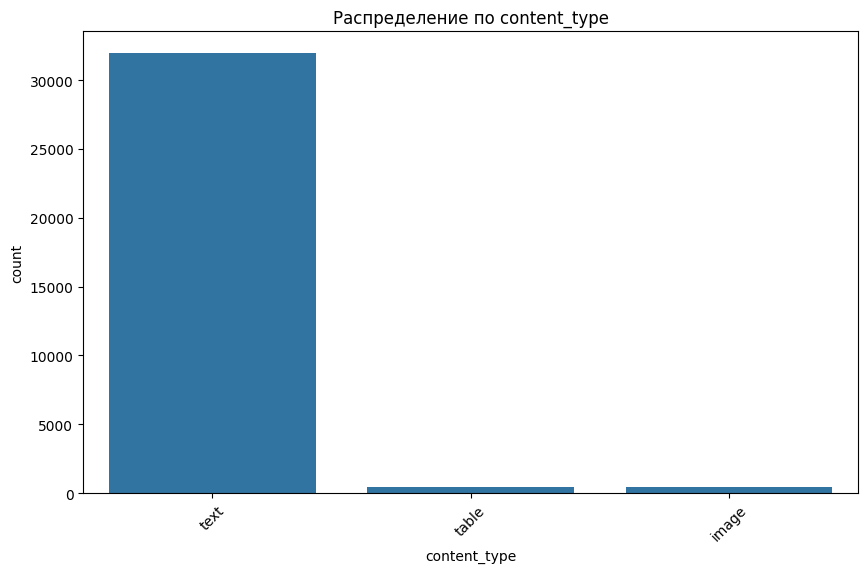

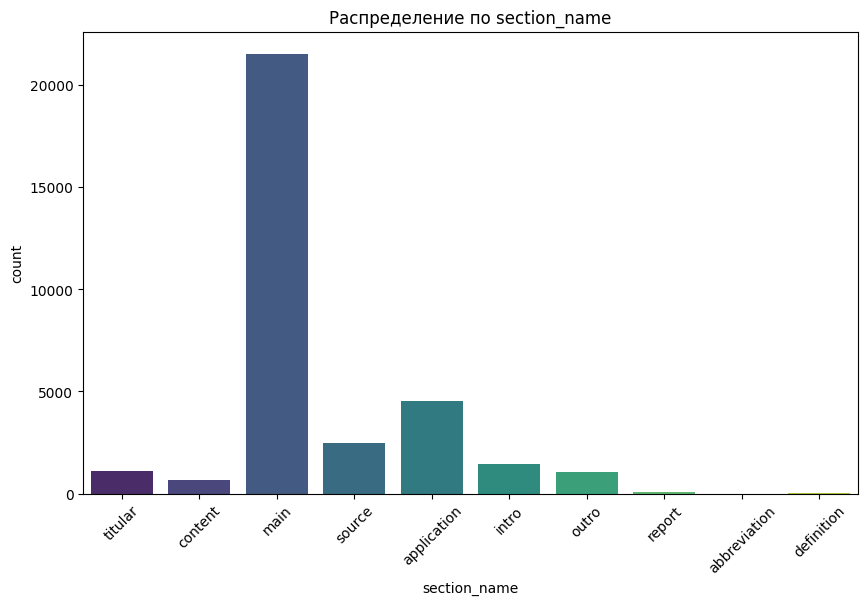

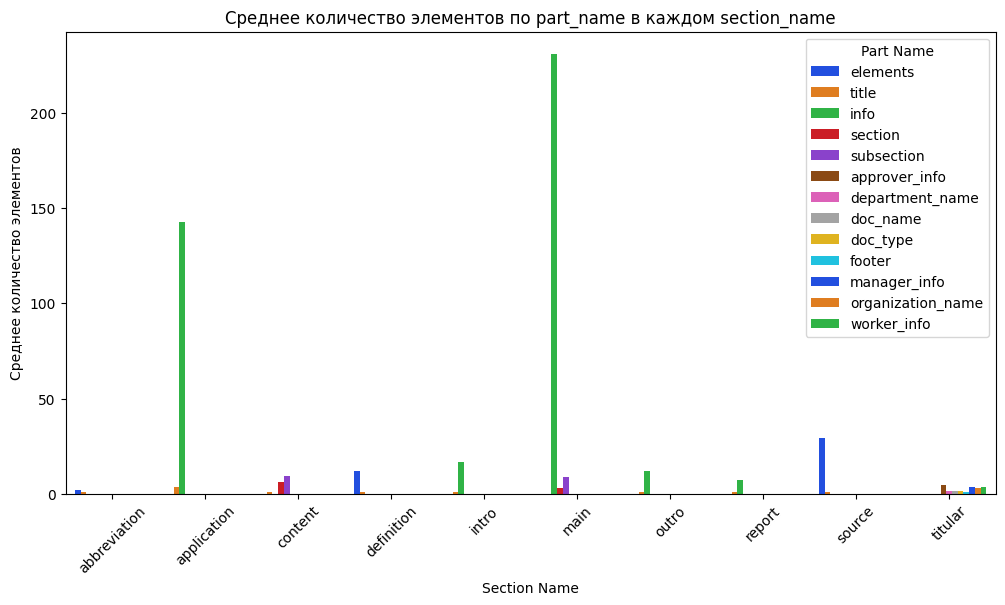

In [ ]:
# 4. Визуализация данных
# Визуализация общего распределения по 'content_type'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='content_type')
plt.title('Распределение по content_type')
plt.xticks(rotation=45)
plt.show()

# Визуализация общего распределения по 'section_name'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='section_name', hue='section_name', legend=False, palette='viridis')
plt.title('Распределение по section_name')
plt.xticks(rotation=45)
plt.show()


grouped = df.groupby(['document_id', 'section_name', 'part_name']).size().reset_index(name='count')
mean_count_per_part = grouped.groupby(['section_name', 'part_name'])['count'].mean().reset_index()

# Визуализация среднего количества элементов по part_name в каждом section_name
plt.figure(figsize=(12, 6))
sns.barplot(data=mean_count_per_part, x='section_name', y='count', hue='part_name', palette='bright')
plt.title('Среднее количество элементов по part_name в каждом section_name')
plt.xlabel('Section Name')
plt.ylabel('Среднее количество элементов')
plt.xticks(rotation=45)
plt.legend(title='Part Name')
plt.show()

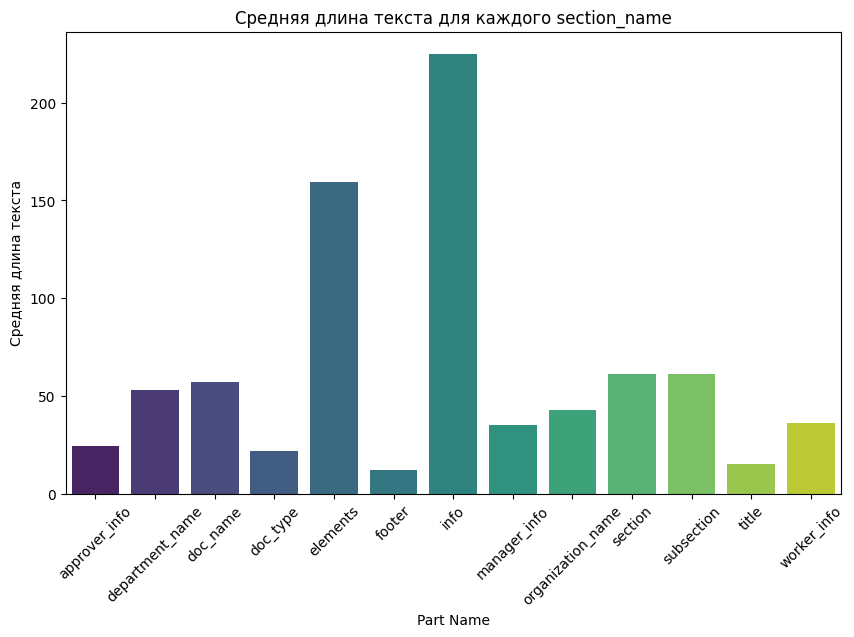

In [ ]:
# 5. Анализ текстовых данных
# Анализ длины текста в 'content_value'
df['content_length'] = df['content_value'].apply(lambda x: len(str(x)))

mean_length_per_section = df.groupby('part_name')['content_length'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=mean_length_per_section,
    x='part_name',
    y='content_length',
    hue='part_name',  # Добавляем hue
    palette='viridis',   # Палитра цветов
    legend=False         # Отключаем легенду
)
plt.title('Средняя длина текста для каждого section_name')
plt.xticks(rotation=45)
plt.xlabel('Part Name')
plt.ylabel('Средняя длина текста')
plt.show()